In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import cftime

time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

In [2]:
my_experiment_name = "amip"
my_runid = "agm-amip-test"
base_path = "/scratch/agmorgan/canesm_runs/{runid}/data/nc_output/CMIP6/CMIP/CP4C/CanESM5-1/{experiment_name}/r1i1p1f1/"
daily_path = "day/{var_name}/gn/v20190429/{var_name}_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"
year_start = 2003
year_end = 2008 + 1
year_range = range(year_start, year_end)

def join_paths(var_name, year_range, experiment_name = "historical"):
    return [
        os.path.join(
            base_path.format(runid = my_runid, experiment_name = experiment_name), 
            daily_path.format(var_name=var_name, year=my_year, experiment_name=experiment_name)) 
            for my_year in year_range
        ]

# All precip
ds_pr_daily = xr.open_mfdataset(
     join_paths("pr", year_range, experiment_name = my_experiment_name),
     decode_times = time_coder,
     data_vars = "all", 
)

# Convective precip 
ds_prc_daily = xr.open_mfdataset(
     join_paths("prc", year_range, experiment_name = my_experiment_name),
     decode_times = time_coder,
     data_vars = "all", 
)

In [3]:
da_eprc = 86400. * ds_prc_daily.prc.groupby("time.year").max(dim="time") # convective precip
da_epr = 86400. * ds_pr_daily.pr.groupby("time.year").max(dim="time") # total precip
da_eprr = (da_epr - da_eprc).mean(dim="year") # resolved
da_eprr_max = da_eprr.max().values

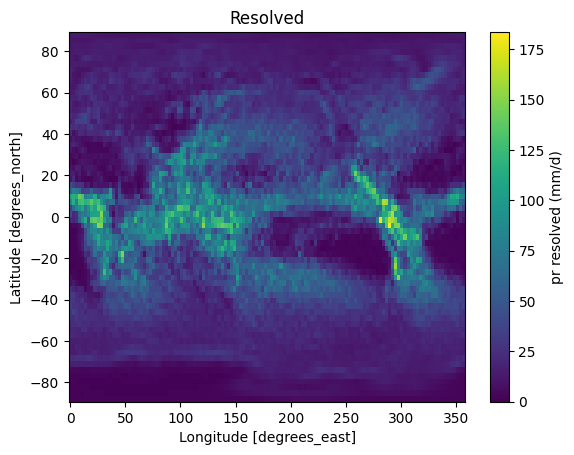

In [4]:
fig, ax = plt.subplots()
CS = da_eprr.plot(vmin=0, vmax=da_eprr_max, cbar_kwargs={"label": "pr resolved (mm/d)"})
plt.title("Resolved")
plt.show()

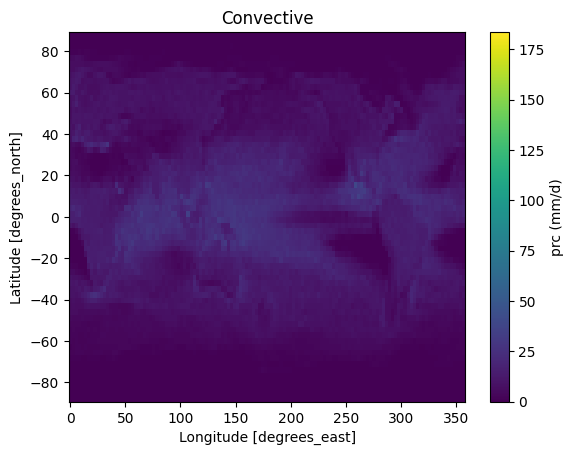

In [5]:
da_eprc.mean(dim="year").plot(vmin=0, vmax=da_eprr_max, cbar_kwargs={"label": "prc (mm/d)"})
plt.title("Convective")
plt.show()

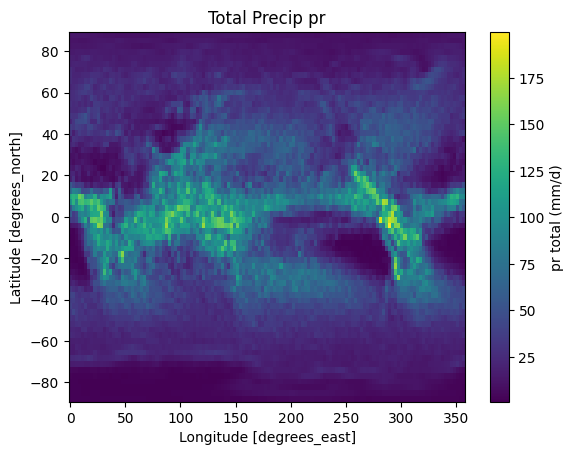

In [6]:
da_epr.mean(dim="year").plot(cbar_kwargs={"label": "pr total (mm/d)"})
plt.title("Total Precip pr")
plt.show()

In [7]:
areacell_path = "fx/areacella/gn/v20190429/areacella_fx_CanESM5-1_{experiment_name}_r1i1p1f1_gn.nc"

def join_paths_areacell(experiment_name = "historical"):
    return os.path.join(
            base_path.format(runid = my_runid, experiment_name = experiment_name), 
            areacell_path.format(experiment_name=experiment_name)) 

ds_areacella = xr.open_dataset(
    join_paths_areacell(my_experiment_name)
)
global_area = ds_areacella.areacella.sum(dim=['lon', 'lat'])         

np.float32(2.8726022)

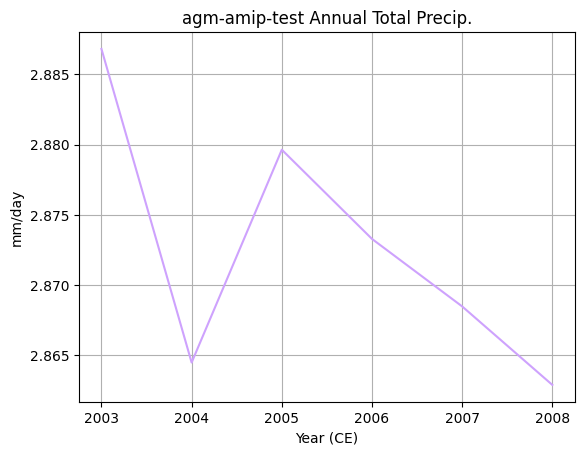

In [13]:
pr_gm = (ds_areacella.areacella * ds_pr_daily.pr).sum(dim=['lon', 'lat']) / global_area # Properly area weighted mean of rate of flux
time_scale = 60*60*24 # Number of seconds in a day 
(time_scale*pr_gm.groupby('time.year').mean(dim='time')).plot(color="xkcd:lilac")
plt.grid()
plt.title("agm-amip-test Annual Total Precip.")
plt.xlabel("Year (CE)")
plt.ylabel("mm/day")
pr_mean = time_scale*pr_gm.mean(dim='time').values
pr_mean